# Modelo Prescritivo

## Funções dos Modelos

- **Modelo preditivo** → estima probabilidades  
- **Modelo prescritivo** → toma decisão ótima com base nessas probabilidades  

## Perguntas que cada UM responde

- **Preditivo**: “Qual a chance?”  
- **Prescritivo**: “O que eu devo fazer?”  

## Ferramenta utilizada

Vamos utilizar  **Otimização Linear Inteira Binária** - 
- Usa equações lineares;
- Busca maximizar ou minimizar algo;
- Só permite decisões 0 ou 1.


# Integração entre Modelo Preditivo e Modelo Prescritivo

## Objetivo

O objetivo desta etapa foi integrar o modelo preditivo (Random Forest) ao modelo prescritivo (Otimização com PuLP), mantendo uma arquitetura modular e organizada.

---

## Estrutura do Projeto

O projeto foi dividido em dois módulos:

- `predictive_model.py` → Responsável por treinar o modelo e gerar probabilidades.
- `prescriptive_model.ipynb` → Responsável por utilizar essas probabilidades para tomar a melhor decisão via otimização matemática.

Essa separação permite reutilização de código e melhor organização do sistema.

---

## Como a Integração Foi Feita

Para importar o modelo preditivo dentro do notebook prescritivo, foi necessário adicionar dinamicamente o diretório ao caminho de execução do Python:

```python
import sys
import os

# Adiciona a pasta do modelo preditivo ao path do Python
sys.path.append(os.path.abspath("../predictive-model"))

from predictive_model import (
    recomendar_top_n,
    modelo,
    le_titulo,
    le_proximo,
    le_periodo
)

## Carregando o Modelo Preditivo

Aqui adicionamos o diretório do modelo preditivo ao path do sistema e importamos:

- `recomendar_top_n`: função que retorna os vídeos mais prováveis
- `modelo`: modelo treinado
- `le_titulo`, `le_proximo`, `le_periodo`: codificadores utilizados no treinamento

In [11]:
## IMPORTAÇÕES
import sys
import os
import pulp
import matplotlib.pyplot as plt
import pandas as pd

# Carregar dados tratados do modelo preditivo
# O arquivo df_modelo_30dias.csv é gerado pelo pipeline de tratamento em data_preparation.ipynb
caminho_csv = os.path.abspath("../predictive-model/df_modelo_30dias.csv")
df_modelo = pd.read_csv(caminho_csv)

df_modelo["data"] = pd.to_datetime(df_modelo["data"])

df_modelo = df_modelo.sort_values("data")

# Exemplo: pegar últimos vídeos assistidos
ultimos_videos = df_modelo["titulo"].tail(10).tolist()
print("Últimos vídeos assistidos:", ultimos_videos)

# ...restante do código de importação do modelo preditivo...
sys.path.append(os.path.abspath("../predictive-model"))
from predictive_model import (
    recomendar_top_n,
    modelo,
    le_titulo,
    le_proximo,
    le_periodo
)


Últimos vídeos assistidos: ['https://www.youtube.com/watch?v=30VagMEospM', 'https://www.youtube.com/watch?v=Ee4JPYNvfaE', 'https://www.youtube.com/watch?v=kxnb-gwo2rk', 'https://www.youtube.com/watch?v=cWrNNL6Fje4', 'https://www.youtube.com/watch?v=l-2LUSxCaRo', 'https://www.youtube.com/watch?v=ByQeHi42Upw', 'https://www.youtube.com/watch?v=n1arSFa2gds', 'https://www.youtube.com/watch?v=r4dbQy7IHE8', 'https://www.youtube.com/watch?v=Ln46Dfn3QRU', 'https://www.youtube.com/watch?v=EPuSc-G3v9A']


In [12]:
video_atual = le_titulo.classes_[0]
periodo = "noite"

resultado = recomendar_top_n(
    video_atual,
    periodo,
    modelo,
    le_titulo,
    le_proximo,
    le_periodo,
    n=3
)

if not resultado:
    print("Nenhuma recomendação encontrada.")
else:
    print("Top-N vindo do modelo:")
    for v, p in resultado:
        print(f"{v} → {p:.2%}")

Top-N vindo do modelo:
https://music.youtube.com/watch?v=CNDYWba7YDY → 45.00%
https://music.youtube.com/watch?v=V3NbrjVPIHM → 18.00%
https://music.youtube.com/watch?v=KjteCvkh0B8 → 16.00%


C:\Users\giovannarosa-ieg\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [13]:
#Problema 
prob=pulp.LpProblem("Recomendacao",pulp.LpMaximize)
print(prob)


Recomendacao:
MAXIMIZE
None
VARIABLES



## Teste Inicial de Recomendação

Selecionamos:

- Um vídeo atual
- Um período do dia

E utilizamos a função `recomendar_top_n()` para obter as 3 recomendações com maiores probabilidades.

Se houver resultados, exibimos:
- Nome do vídeo recomendado
- Probabilidade estimada

In [14]:
# Testar com dado do dataSeat
print(le_titulo.classes_[:5])

['https://music.youtube.com/watch?v=-3gkan9wSaQ'
 'https://music.youtube.com/watch?v=-KrC-gqKTMg'
 'https://music.youtube.com/watch?v=-Uw97CvOgKU'
 'https://music.youtube.com/watch?v=-ZBMFq4-gQ4'
 'https://music.youtube.com/watch?v=-aytZ0n_KNQ']


In [15]:
video_teste = le_titulo.classes_[0]
periodo_teste = "noite"

video_teste = le_titulo.classes_[0]
periodo_teste = "noite"

resultado = recomendar_top_n(
    video_teste,
    periodo_teste,
    modelo,
    le_titulo,
    le_proximo,
    le_periodo,
    n=3
)

print("\n RECOMENDAÇÕES GERADAS")
print(f"Vídeo atual: {video_teste}")
print(f"Período: {periodo_teste}")
print("-" * 50)

if resultado:
    for i, (link, proba) in enumerate(resultado, start=1):
        print(f"{i}º lugar")
        print(f" Link: {link}")
        print(f" Probabilidade estimada: {proba:.2%}")
        print("-" * 50)
else:
    print("Nenhuma recomendação encontrada.")


 RECOMENDAÇÕES GERADAS
Vídeo atual: https://music.youtube.com/watch?v=-3gkan9wSaQ
Período: noite
--------------------------------------------------
1º lugar
 Link: https://music.youtube.com/watch?v=CNDYWba7YDY
 Probabilidade estimada: 45.00%
--------------------------------------------------
2º lugar
 Link: https://music.youtube.com/watch?v=V3NbrjVPIHM
 Probabilidade estimada: 18.00%
--------------------------------------------------
3º lugar
 Link: https://music.youtube.com/watch?v=KjteCvkh0B8
 Probabilidade estimada: 16.00%
--------------------------------------------------


C:\Users\giovannarosa-ieg\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [16]:
# Variáveis Binárias
videos = [v for v, _ in resultado]
probas = {v: p for v, p in resultado}

# Criar variáveis binárias para cada vídeo candidato
x = pulp.LpVariable.dicts("video", videos, cat='Binary')

print("videos:", videos)
print("probas:", probas)



videos: ['https://music.youtube.com/watch?v=CNDYWba7YDY', 'https://music.youtube.com/watch?v=V3NbrjVPIHM', 'https://music.youtube.com/watch?v=KjteCvkh0B8']
probas: {'https://music.youtube.com/watch?v=CNDYWba7YDY': np.float64(0.45), 'https://music.youtube.com/watch?v=V3NbrjVPIHM': np.float64(0.18), 'https://music.youtube.com/watch?v=KjteCvkh0B8': np.float64(0.16)}


## Definição do Problema de Programação Linear

Criamos um problema utilizando PuLP:

- Nome: "Recomendacao"
- Tipo: Maximização

O objetivo será escolher o vídeo com maior tempo de retenção.

In [18]:
# Restrições - Vamos escolher apenas um video 
prob+=pulp.lpSum([x[v]for v in videos])==1
print(prob)


Recomendacao:
MAXIMIZE
None
SUBJECT TO
_C1: video_https:__music.youtube.com_watch?v=CNDYWba7YDY
 + video_https:__music.youtube.com_watch?v=KjteCvkh0B8
 + video_https:__music.youtube.com_watch?v=V3NbrjVPIHM = 1

VARIABLES
0 <= video_https:__music.youtube.com_watch?v=CNDYWba7YDY <= 1 Integer
0 <= video_https:__music.youtube.com_watch?v=KjteCvkh0B8 <= 1 Integer
0 <= video_https:__music.youtube.com_watch?v=V3NbrjVPIHM <= 1 Integer



In [ ]:
# Definir número de recomendações
N_RECOMENDACOES = 1

# Obter vídeos já assistidos recentemente para não recomendar de novo
videos_assistidos = set(ultimos_videos)

# Extrair lista de vídeos candidatos vindos do preditivo, agora com retenção esperada
# resultado deve ser uma lista de tuplas: (video, probabilidade, retencao_prevista)
videos = [v for v, _, _ in resultado]

# Dicionário de retenção esperada para cada vídeo, vindo do preditivo
retencao_esperada = {v: r for v, _, r in resultado}

# Dicionário de categorias dos vídeos (exemplo: pode ser carregado de um dataset)
video_categoria = {v: 'Categoria' for v in videos}  # Aqui está fixo, mas pode ser personalizado

# Definir categorias proibidas (exemplo: pode ser um input do usuário ou regra de negócio)
categorias_proibidas = set()

# Criar variáveis binárias para cada vídeo candidato
x = pulp.LpVariable.dicts("video", videos, cat='Binary')

# Criar o problema de otimização
prob = pulp.LpProblem("Recomendacao", pulp.LpMaximize)

# Função objetivo: maximizar a soma da retenção esperada dos vídeos recomendados
prob += pulp.lpSum([retencao_esperada.get(v, 0) * x[v] for v in videos])

# Restrição: recomendar exatamente 1 vídeo
prob += pulp.lpSum([x[v] for v in videos]) == 1

# Não recomendar vídeos já assistidos
for v in videos:
    if v in videos_assistidos:
        prob += x[v] == 0

# Não recomendar vídeos de categorias proibidas
for v in videos:
    if video_categoria.get(v) in categorias_proibidas:
        prob += x[v] == 0

# Resolver o problema
prob.solve()

# Exibir recomendação
for v in videos:
    if x[v].value() == 1:
        print(f"Recomendar: {v} | retenção esperada: {retencao_esperada.get(v, 'N/A')}s")


Recomendar: https://music.youtube.com/watch?v=V3NbrjVPIHM | retenção esperada: 60s


# Feature Importance

Extraímos:

- `feature_importances_`
- `feature_names_in_`

Criamos um DataFrame ordenado para visualizar quais variáveis mais influenciam a previsão do modelo.

In [20]:
print(type(modelo))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [21]:

importancias = modelo.feature_importances_

nomes_features = modelo.feature_names_in_

df_importancia = pd.DataFrame({
    "Feature": nomes_features,
    "Importância": importancias
}).sort_values(by="Importância", ascending=False)

print(df_importancia)

           Feature  Importância
0   titulo_encoded     0.963024
1  periodo_encoded     0.036976


## Gráfico Feature Importance

Construímos um gráfico de barras mostrando:

- Eixo X: Features
- Eixo Y: Grau de importância

Isso permite interpretar quais variáveis mais impactam na decisão do modelo preditivo.

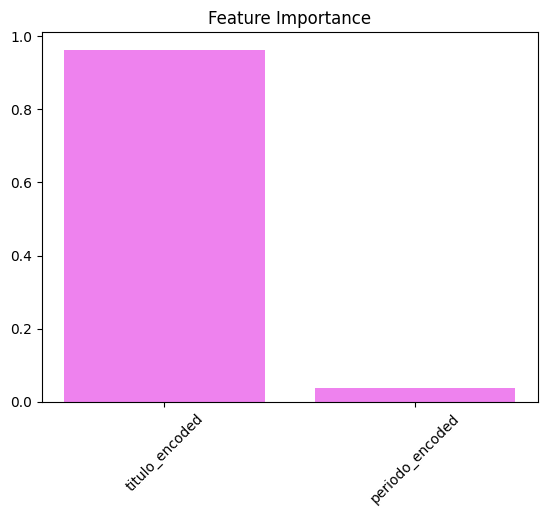

In [22]:

plt.figure()
plt.bar(df_importancia["Feature"], df_importancia["Importância"], color='violet')
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()